In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore')


In [3]:
df = pd.read_csv('heart.csv')
print("Dataset shape:", df.shape)
df.head()

Dataset shape: (303, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [5]:
print("Checking for missing values:", df.isnull().sum().sum())
print(df['target'].value_counts())
print(f"balance: {df['target'].value_counts().min() / df['target'].value_counts().max()}")

Checking for missing values: 0
target
1    165
0    138
Name: count, dtype: int64
balance: 0.8363636363636363


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


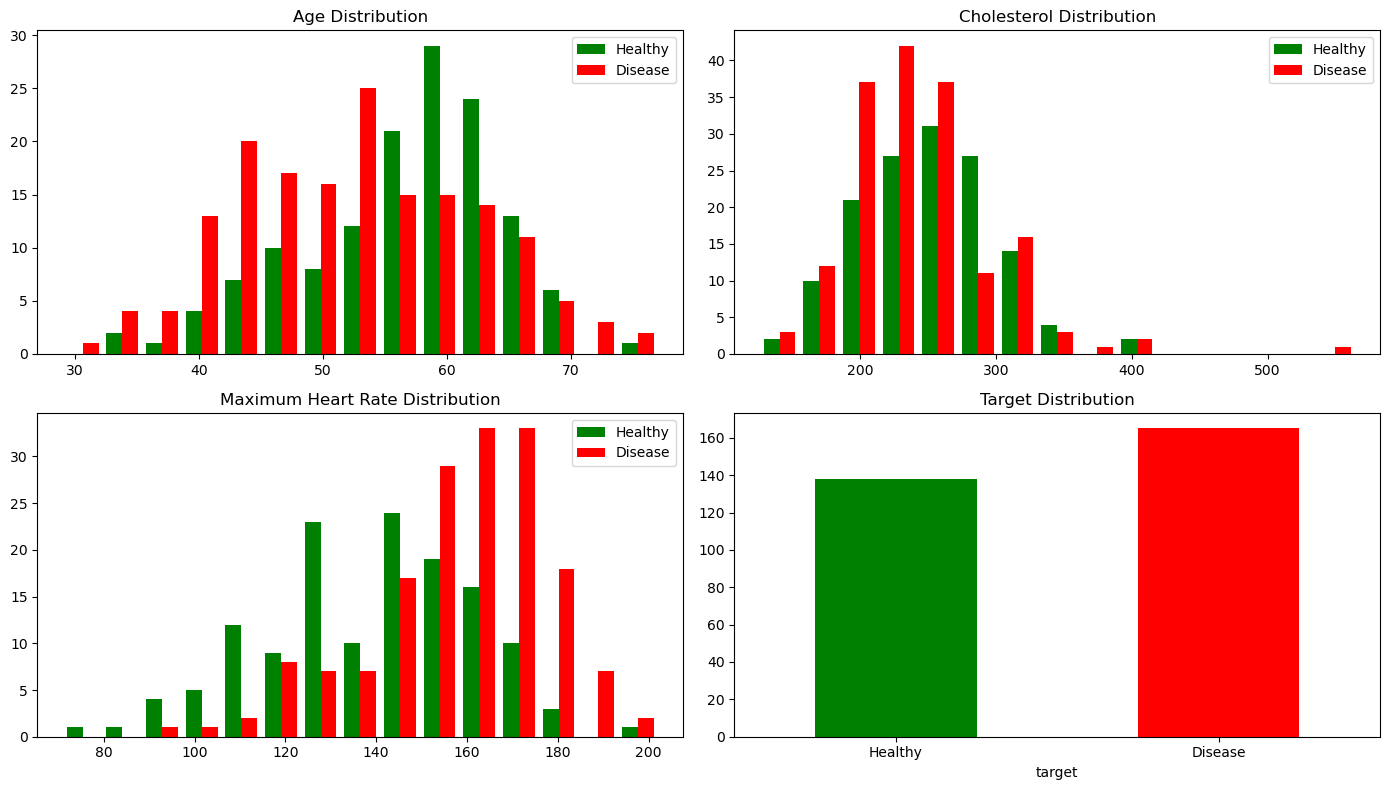

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Age Distribution
axes[0, 0].hist(
    [df[df['target'] == 0]['age'],
     df[df['target'] == 1]['age']],
    label=['Healthy', 'Disease'],
    bins=15,
    color=['green', 'red']
)
axes[0, 0].set_title('Age Distribution')
axes[0, 0].legend()

# Cholesterol Distribution
axes[0, 1].hist(
    [df[df['target'] == 0]['chol'],
     df[df['target'] == 1]['chol']],
    label=['Healthy', 'Disease'],
    bins=15,
    color=['green', 'red']
)
axes[0, 1].set_title('Cholesterol Distribution')
axes[0, 1].legend()

# Maximum Heart Rate Distribution
axes[1, 0].hist(
    [df[df['target'] == 0]['thalach'],
     df[df['target'] == 1]['thalach']],
    label=['Healthy', 'Disease'],
    bins=15,
    color=['green', 'red']
)
axes[1, 0].set_title('Maximum Heart Rate Distribution')
axes[1, 0].legend()

# Target Distribution
df['target'].value_counts().sort_index().plot(
    kind='bar',
    ax=axes[1, 1],
    color=['green', 'red']
)
axes[1, 1].set_title('Target Distribution')
axes[1, 1].set_xticklabels(['Healthy', 'Disease'], rotation=0)

plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'Correlation Heatmap')

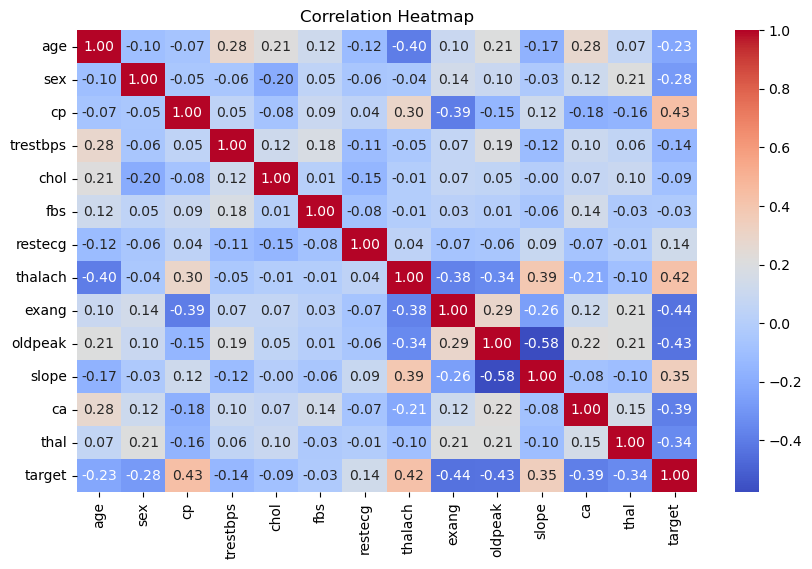

In [14]:
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')

In [15]:
x = df.drop('target', axis=1)
y = df['target']

print(x.shape, y.shape)

(303, 13) (303,)


In [18]:
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2, random_state=42)
print(x_train.shape[0], y_test.shape[0])

242 61
